# eda para previsão de preços de passagens aéreas

**objetivo:** entender o comportamento de `price` e identificar os principais drivers de preço antes da etapa de modelagem.

**dataset:** `Clean_Dataset.csv`

**perguntas da investigação:**

1. a base original está íntegra para modelagem?
2. como as variáveis originais se distribuem?
3. `price` é assimétrico? uma transformação log ajuda?
4. quais atributos parecem explicar melhor o preço?
5. reservar com antecedência afeta `Economy` e `Business` do mesmo jeito?


## glossário das variáveis

### variáveis da base

- `Unnamed: 0`: índice artificial do arquivo original. não é uma feature de negócio e pode ser removida da análise/modelagem
- `airline`: companhia aérea responsável pelo voo, por exemplo `Vistara`, `Air_India`, `Indigo`
- `flight`: identificador do voo, normalmente composto por código da companhia + número do voo, por exemplo `SG-8709`
- `source_city`: cidade de origem do voo
- `departure_time`: faixa do horário de partida do voo. é uma categoria agregada, não o horário exato
- `stops`: quantidade de escalas/paradas no trajeto
- `arrival_time`: faixa do horário de chegada do voo. também é uma categoria agregada
- `destination_city`: cidade de destino do voo
- `class`: classe da passagem, como `Economy` ou `Business`
- `duration`: duração total da viagem em horas
- `days_left`: número de dias entre a data da compra/consulta e a data do voo
- `price`: preço da passagem. esta é a variável-alvo (`target`) do problema

### variáveis derivadas criadas

- `route`: combinação de origem e destino, por exemplo `Delhi -> Mumbai`. ajuda a representar o trajeto de forma direta
- `is_business`: indicador binário da classe executiva. vale `1` para `Business` e `0` caso contrário
- `is_nonstop`: indicador binário de voo sem escala. vale `1` quando `stops = zero`
- `same_slot`: indicador binário que marca se partida e chegada caem na mesma faixa de horário
- `log_price`: transformação `log1p(price)`, usada para analisar a assimetria da variável-alvo
- `days_bin`: agrupamento de `days_left` em faixas de antecedência, como `1-7`, `8-14` e assim por diante

### observações

- `departure_time` e `arrival_time` representam janelas do dia, como `Morning`, `Evening` e `Night`, e não horários exatos em formato `hh:mm`
- as variáveis derivadas acima não pertencem à base bruta. elas serão criadas apenas quando entrarem nas hipóteses analíticas

In [57]:
import os
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy import stats
from scipy.stats import pearsonr, spearmanr, skew
warnings.filterwarnings("ignore")

PALETA_GRAFICOS = [
    "#A8DADC",
    "#FFCAD4",
    "#CDEAC0",
    "#C7CEEA",
    "#FFD6A5",
    "#BDE0FE",
    "#E4C1F9",
    "#F1C0E8",
]

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")
sns.set_palette(PALETA_GRAFICOS)
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=PALETA_GRAFICOS)
RANDOM_STATE = 42

In [58]:
def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd.parent,
        cwd / "03-flight-price-prediction",
        cwd.parent / "03-flight-price-prediction",
    ]
    for candidate in candidates:
        if (candidate / "data" / "Clean_Dataset.csv").exists():
            return candidate
    raise FileNotFoundError("nao encontrei data/Clean_Dataset.csv")


PROJECT_ROOT = resolve_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "Clean_Dataset.csv"

os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / "notebooks" / ".mplconfig"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

In [59]:
df_raw = pd.read_csv(DATA_PATH).drop(columns=["Unnamed: 0"]).copy()

print(f"dataset carregado de: {DATA_PATH}")
print(f"shape da base original: {df_raw.shape}")
display(pd.DataFrame({"colunas": df_raw.columns}))
display(df_raw.head())

dataset carregado de: /Users/jessicafalcundes/Desktop/machine-learning-projects/03-flight-price-prediction/data/Clean_Dataset.csv
shape da base original: (300153, 11)


,colunas
0,airline
1,flight
2,source_city
3,departure_time
4,stops
5,arrival_time
6,destination_city
7,class
8,duration
9,days_left


,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.1700,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.3300,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.1700,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.2500,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.3300,1,5955


## estatísticas descritivas

In [60]:
num_cols = df_raw.select_dtypes(include=np.number).columns
cat_cols = df_raw.select_dtypes(exclude=np.number).columns

desc_num = df_raw[num_cols].describe().T
desc_cat = df_raw[cat_cols].describe().T
desc_cat["freq"] = pd.to_numeric(desc_cat["freq"], errors="coerce")
desc_cat["top_pct"] = desc_cat["freq"].div(len(df_raw)).mul(100).round(2)

display(desc_num)
display(desc_cat[["count", "unique", "top", "freq", "top_pct"]])

,count,mean,std,min,25%,50%,75%,max
duration,"300,153.0000",12.2210,7.1920,0.8300,6.8300,11.2500,16.1700,49.8300
days_left,"300,153.0000",26.0048,13.5610,1.0000,15.0000,26.0000,38.0000,49.0000
price,"300,153.0000","20,889.6605","22,697.7674","1,105.0000","4,783.0000","7,425.0000","42,521.0000","123,071.0000"


,count,unique,top,freq,top_pct
airline,300153,6,Vistara,127859,42.6000
flight,300153,1561,UK-706,3235,1.0800
source_city,300153,6,Delhi,61343,20.4400
departure_time,300153,6,Morning,71146,23.7000
stops,300153,3,one,250863,83.5800
arrival_time,300153,6,Night,91538,30.5000
destination_city,300153,6,Mumbai,59097,19.6900
class,300153,2,Economy,206666,68.8500


## roteiro da análise

1. visão geral da base original
2. qualidade dos dados
3. distribuição das variáveis originais
4. análise da variável-alvo `price`
5. criação da camada analítica para testar hipóteses
6. relações entre atributos e target
7. antecedência, classe e rota
8. implicações para modelagem


## 1. visão geral da base original


In [61]:
overview = pd.DataFrame(
    {
        "n_linhas": [df_raw.shape[0]],
        "n_colunas": [df_raw.shape[1]],
        "price_mean": [df_raw["price"].mean()],
        "price_median": [df_raw["price"].median()],
        "n_routes": [df_raw[["source_city", "destination_city"]].drop_duplicates().shape[0]],
        "n_flights": [df_raw["flight"].nunique()],
    }
)

display(overview)

display(
    pd.DataFrame(
        {
            "dtype": df_raw.dtypes.astype(str),
            "nulls": df_raw.isna().sum(),
            "n_unique": df_raw.nunique(),
        }
    )
)

,n_linhas,n_colunas,price_mean,price_median,n_routes,n_flights
0,300153,11,"20,889.6605","7,425.0000",30,1561


,dtype,nulls,n_unique
airline,object,0,6
flight,object,0,1561
source_city,object,0,6
departure_time,object,0,6
stops,object,0,3
arrival_time,object,0,6
destination_city,object,0,6
class,object,0,2
duration,float64,0,476
days_left,int64,0,49


## 2. qualidade dos dados

- checagem de valores faltantes e duplicatas completas
- leitura do peso relativo das principais categorias

In [62]:
quality_report = pd.DataFrame(
    {
        "missing": df_raw.isna().sum(),
        "missing_pct": df_raw.isna().mean().mul(100).round(2),
    }
)

print("duplicatas completas:", int(df_raw.duplicated().sum()))
display(quality_report)

cat_share = {
    "class": df_raw["class"].value_counts(normalize=True).mul(100).round(2),
    "stops": df_raw["stops"].value_counts(normalize=True).mul(100).round(2),
    "airline": df_raw["airline"].value_counts(normalize=True).mul(100).round(2),
}

for col, series in cat_share.items():
    print(f"\n{col}")
    display(series.rename("pct"))

duplicatas completas: 0


,missing,missing_pct
airline,0,0.0000
flight,0,0.0000
source_city,0,0.0000
departure_time,0,0.0000
stops,0,0.0000
arrival_time,0,0.0000
destination_city,0,0.0000
class,0,0.0000
duration,0,0.0000
days_left,0,0.0000



class


class
Economy    68.8500
Business   31.1500
Name: pct, dtype: float64


stops


stops
one           83.5800
zero          12.0000
two_or_more    4.4300
Name: pct, dtype: float64


airline


airline
Vistara     42.6000
Air_India   26.9500
Indigo      14.3700
GO_FIRST     7.7200
AirAsia      5.3600
SpiceJet     3.0000
Name: pct, dtype: float64

a base está estruturalmente limpa, sem nulos e sem duplicatas completas. percebemos que a amostra é puxada por `Economy`, por voos com `one stop` e por poucas companhias. então, qualquer média global de `price` corre o risco de esconder efeitos importantes agregados nessas categorias

## 3. distribuição das variáveis

leitura da base bruta para entendimento do problema

- `duration` e `days_left` resumem a parte numérica principal fora da target
- categorias como `class`, `stops`, `airline` e cidades mostram a cobertura da base

,count,mean,std,min,25%,50%,75%,max
duration,"300,153.0000",12.2210,7.1920,0.8300,6.8300,11.2500,16.1700,49.8300
days_left,"300,153.0000",26.0048,13.5610,1.0000,15.0000,26.0000,38.0000,49.0000


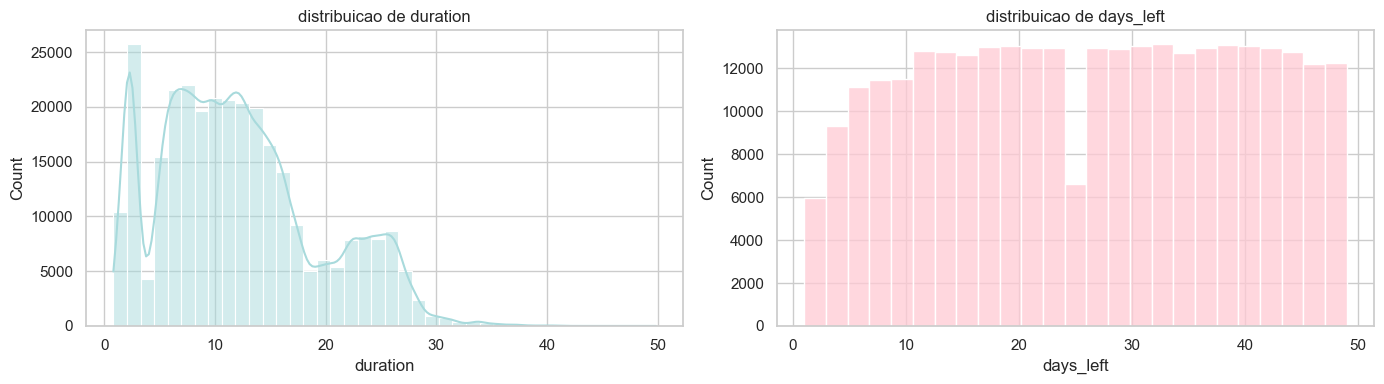

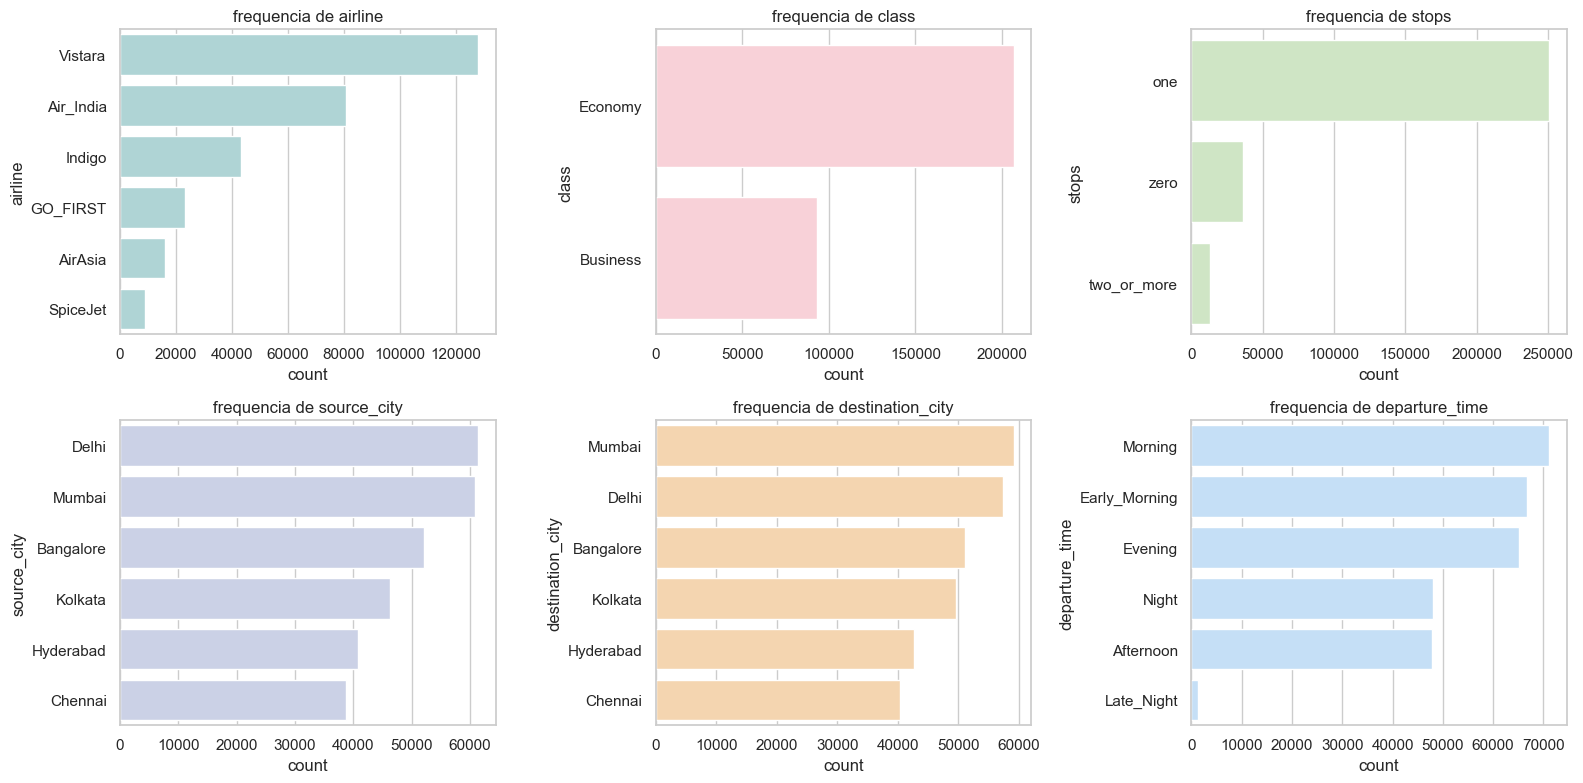

In [63]:
num_desc = df_raw[["duration", "days_left"]].describe().T
display(num_desc)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df_raw["duration"], bins=40, kde=True, ax=axes[0], color=PALETA_GRAFICOS[0])
axes[0].set_title("distribuicao de duration")

sns.histplot(df_raw["days_left"], bins=25, kde=False, ax=axes[1], color=PALETA_GRAFICOS[1])
axes[1].set_title("distribuicao de days_left")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for idx, (ax, col) in enumerate(zip(
    axes.ravel(),
    ["airline", "class", "stops", "source_city", "destination_city", "departure_time"],
)):
    order = df_raw[col].value_counts().index
    sns.countplot(data=df_raw, y=col, order=order, ax=ax, color=PALETA_GRAFICOS[idx % len(PALETA_GRAFICOS)])
    ax.set_title(f"frequencia de {col}")
plt.tight_layout()
plt.show()


analisando as variáveis numéricas, `days_left` está relativamente bem distribuída ao longo da janela de `1` a `49` dias. `duration`, por outro lado, é mais heterogênea e assimétrica, sua mediana fica em `11.25h` e existe uma cauda longa que vai até quase `50h`, sinal de que o dataset mistura perfis de voo bem distintos em vez de girar em torno de um trajeto específico

nas variáveis categóricas, observamos um desbalanceamento. `Economy` domina sobre `Business`, voos com `one stop` concentram a maior parte das observações e poucas companhias carregam grande parte da amostra. isso importa porque médias globais de `price` ou até de `duration` podem acabar refletindo muito mais a composição dominante da base do que o efeito isolado de cada variável.

## 4. variável-alvo `price`

investigação da target para verificar assimetria, dispersão e a utilidade de uma transformação log

- `price` é bastante assimétrica à direita
- `log1p(price)` tende a reduzir essa assimetria
- o boxplot ajuda a separar cauda longa de erro de coleta

,value
mean_price,"20,889.6605"
median_price,"7,425.0000"
std_price,"22,697.7674"
skew_price,1.0614
skew_log_price,0.4045
iqr_upper_bound,"99,128.0000"
outliers_above_iqr,123.0000
outlier_pct,0.0410


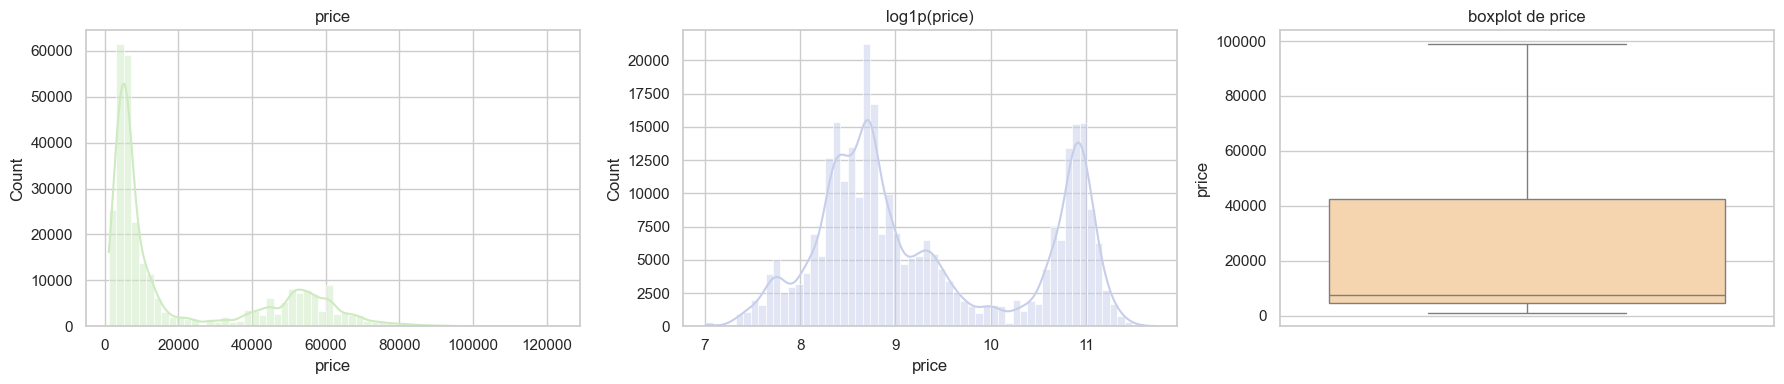

In [64]:
log_price = np.log1p(df_raw["price"])
q1, q3 = df_raw["price"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

target_summary = pd.Series(
    {
        "mean_price": df_raw["price"].mean(),
        "median_price": df_raw["price"].median(),
        "std_price": df_raw["price"].std(),
        "skew_price": skew(df_raw["price"]),
        "skew_log_price": skew(log_price),
        "iqr_upper_bound": upper_bound,
        "outliers_above_iqr": int((df_raw["price"] > upper_bound).sum()),
        "outlier_pct": (df_raw["price"] > upper_bound).mean() * 100,
    }
).round(4).to_frame("value")

display(target_summary)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(df_raw["price"], bins=60, kde=True, ax=axes[0], color=PALETA_GRAFICOS[2])
axes[0].set_title("price")

sns.histplot(log_price, bins=60, kde=True, ax=axes[1], color=PALETA_GRAFICOS[3])
axes[1].set_title("log1p(price)")

sns.boxplot(data=df_raw, y="price", ax=axes[2], color=PALETA_GRAFICOS[4], showfliers=False)
axes[2].set_title("boxplot de price")

plt.tight_layout()
plt.show()

`price` é uma target assimétrica à direita, puxada por um grupo de tarifas mais altas. a diferença entre média (`20.9k`) e mediana (`7.4k`) mostra que o centro da distribuição não está bem representado pela média. 
a transformação `log1p(price)` melhora bastante a forma da distribuição (`skew` cai de `1.06` para `0.40`), mas não apaga totalmente a estrutura em múltiplos picos. 
isso sugere uma mistura de segmentos de preço dentro da base, muito provavelmente associada a variáveis como `class`, rota e características operacionais do voo. 
o fato de o IQR sinalizar só `0.04%` de outliers reforça que os preços altos parecem fazer parte do padrão do negócio, não são apenas ruídos isolados

## 5. hipóteses

- `route` junta origem e destino em uma única feature de trajeto
- `is_business` e `is_nonstop` transformam categorias centrais em indicadores simples
- `same_slot` tenta capturar alinhamento entre janela de partida e chegada
- `days_bin` agrupa a antecedência para leituras menos ruidosas

In [65]:
df = df_raw.copy()
df["route"] = df["source_city"] + " -> " + df["destination_city"]
df["is_business"] = (df["class"] == "Business").astype(int)
df["is_nonstop"] = (df["stops"] == "zero").astype(int)
df["same_slot"] = (df["departure_time"] == df["arrival_time"]).astype(int)
df["log_price"] = np.log1p(df["price"])
df["days_bin"] = pd.cut(
    df["days_left"],
    bins=[0, 7, 14, 21, 28, 35, 42, 49],
    labels=["1-7", "8-14", "15-21", "22-28", "29-35", "36-42", "43-49"],
)

print(f"shape da base original: {df_raw.shape}")
print(f"shape da camada analitica: {df.shape}")
print(f"linhas preservadas: {df.shape[0] == df_raw.shape[0]}")
display(pd.DataFrame({"novas_colunas": ["route", "is_business", "is_nonstop", "same_slot", "log_price", "days_bin"]}))
display(df.head())

shape da base original: (300153, 11)
shape da camada analitica: (300153, 17)
linhas preservadas: True


,novas_colunas
0,route
1,is_business
2,is_nonstop
3,same_slot
4,log_price
5,days_bin


,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,route,is_business,is_nonstop,same_slot,log_price,days_bin
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.1700,1,5953,Delhi -> Mumbai,0,1,0,8.6918,1-7
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.3300,1,5953,Delhi -> Mumbai,0,1,0,8.6918,1-7
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.1700,1,5956,Delhi -> Mumbai,0,1,1,8.6923,1-7
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.2500,1,5955,Delhi -> Mumbai,0,1,0,8.6922,1-7
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.3300,1,5955,Delhi -> Mumbai,0,1,1,8.6922,1-7


## 6. relação das variáveis com a target

principais hipóteses

- `class` deve ser o principal driver de preço
- `duration` tende a subir junto com `price`
- `days_left` deve ter relação negativa, principalmente em `Economy`
- `stops` precisa de leitura conjunta com `class`, porque a média agregada pode esconder composição

,feature,pearson_r,pearson_p,spearman_r,spearman_p
2,is_business,0.9379,0.0000,0.8016,0.0000
0,duration,0.2042,0.0000,0.3188,0.0000
4,same_slot,-0.0327,0.0000,-0.0463,0.0000
1,days_left,-0.0919,0.0000,-0.2670,0.0000
3,is_nonstop,-0.1873,0.0000,-0.2610,0.0000


,count,mean,median,std
class,,,,
Business,93487,"52,540.0800","53,164.0000","12,969.3100"
Economy,206666,"6,572.3400","5,772.0000","3,743.5200"


,count,mean,median,std
stops,,,,
one,250863,"22,900.9900","7,959.0000","23,626.0700"
two_or_more,13286,"14,113.4500","8,307.0000","17,664.3300"
zero,36004,"9,375.9400","4,499.0000","10,623.0100"


,count,mean,median,std
airline,,,,
Vistara,127859,"30,396.5400","15,543.0000","25,637.1600"
Air_India,80892,"23,507.0200","11,520.0000","20,905.1200"
SpiceJet,9011,"6,179.2800","5,654.0000","2,999.6300"
GO_FIRST,23173,"5,652.0100","5,336.0000","2,513.8700"
Indigo,43120,"5,324.2200","4,453.0000","3,268.8900"
AirAsia,16098,"4,091.0700","3,276.0000","2,824.0600"


count        mean      median
class    stops                                      
Business one           84302 54,687.3800 54,608.0000
         two_or_more    1083 70,127.6600 68,743.0000
         zero           8102 27,846.3400 27,864.0000
Economy  one          166561  6,812.8600  5,937.0000
         two_or_more   12203  9,142.2600  8,012.0000
         zero          27902  4,012.6200  3,531.0000

welch business vs economy: TtestResult(statistic=np.float64(1063.8446994193012), pvalue=np.float64(0.0), df=np.float64(100600.83580335997))
anova airline: F_onewayResult(statistic=np.float64(17194.402096092334), pvalue=np.float64(0.0))
anova stops: F_onewayResult(statistic=np.float64(6477.130362486221), pvalue=np.float64(0.0))
anova departure_time: F_onewayResult(statistic=np.float64(319.2424834073481), pvalue=np.float64(0.0))


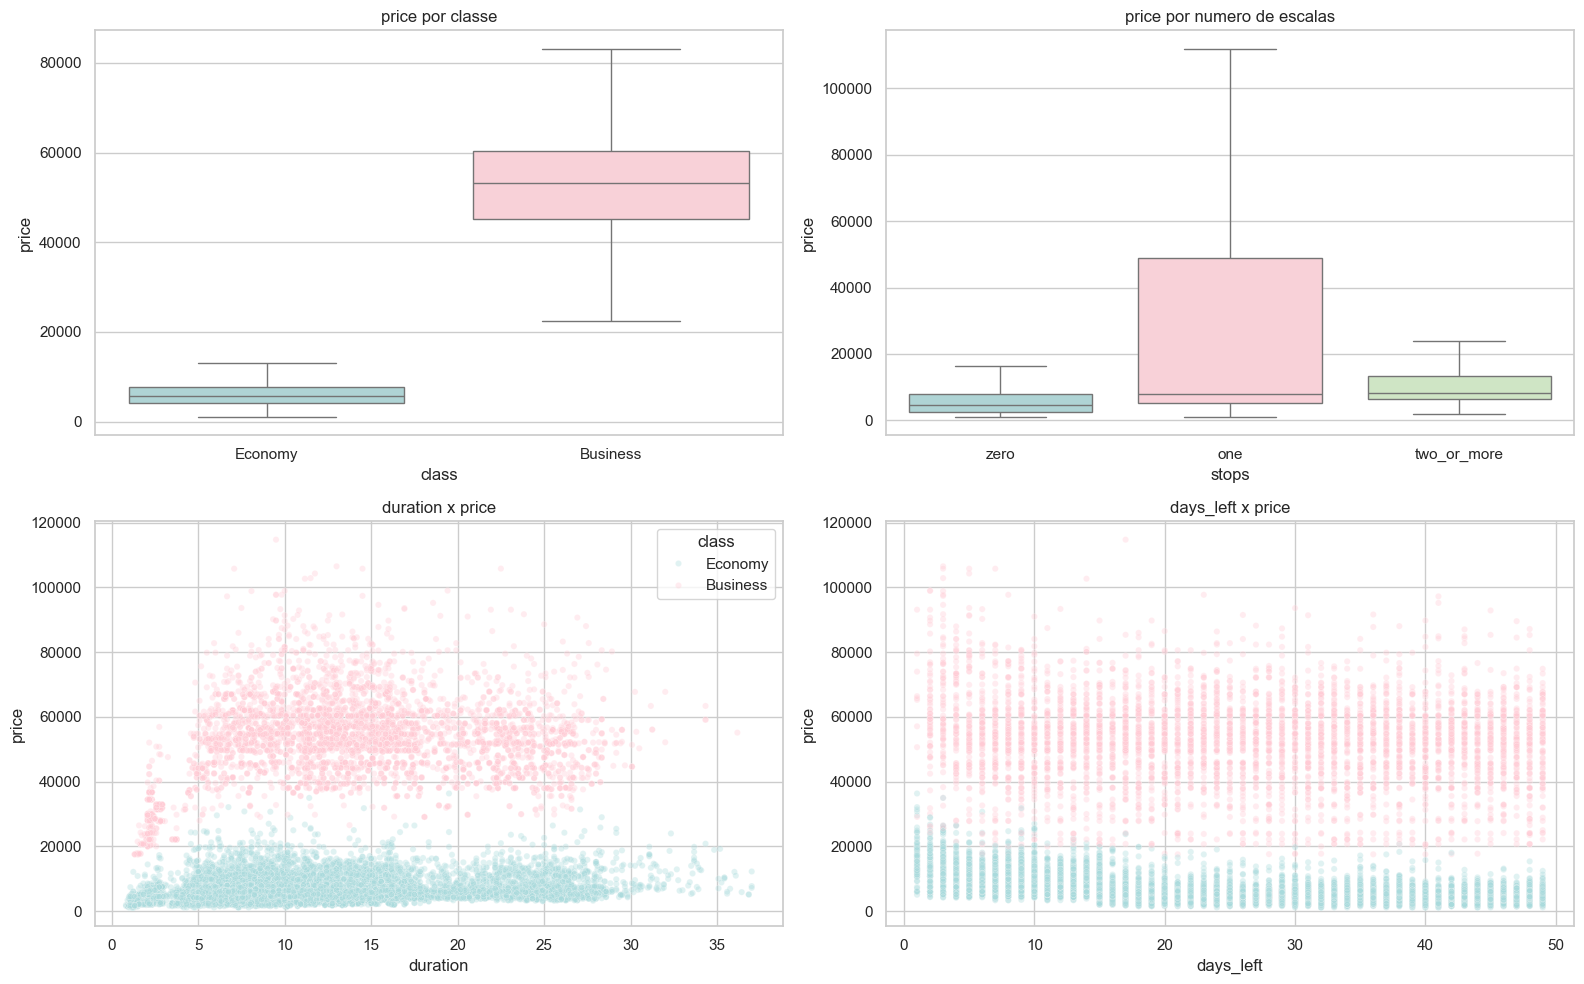

In [66]:
corr_rows = []
for col in ["duration", "days_left", "is_business", "is_nonstop", "same_slot"]:
    pear = pearsonr(df[col], df["price"])
    spear = spearmanr(df[col], df["price"])
    corr_rows.append(
        {
            "feature": col,
            "pearson_r": pear.statistic,
            "pearson_p": pear.pvalue,
            "spearman_r": spear.statistic,
            "spearman_p": spear.pvalue,
        }
    )

corr_df = pd.DataFrame(corr_rows).sort_values("pearson_r", ascending=False).round(4)
display(corr_df)

class_summary = df.groupby("class")["price"].agg(["count", "mean", "median", "std"]).round(2)
stops_summary = df.groupby("stops")["price"].agg(["count", "mean", "median", "std"]).round(2)
airline_summary = (
    df.groupby("airline")["price"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
    .round(2)
)
class_x_stops = df.groupby(["class", "stops"])["price"].agg(["count", "mean", "median"]).round(2)

display(class_summary)
display(stops_summary)
display(airline_summary)
display(class_x_stops)

print("welch business vs economy:", stats.ttest_ind(*[g["price"].values for _, g in df.groupby("class")], equal_var=False))
print("anova airline:", stats.f_oneway(*[g["price"].values for _, g in df.groupby("airline")]))
print("anova stops:", stats.f_oneway(*[g["price"].values for _, g in df.groupby("stops")]))
print("anova departure_time:", stats.f_oneway(*[g["price"].values for _, g in df.groupby("departure_time")]))

sample = df.sample(min(len(df), 15000), random_state=RANDOM_STATE)
palette_classes = PALETA_GRAFICOS[: df["class"].nunique()]
palette_stops = PALETA_GRAFICOS[: df["stops"].nunique()]
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.boxplot(data=df, x="class", y="price", hue="class", dodge=False, showfliers=False, ax=axes[0, 0], palette=palette_classes)
axes[0, 0].set_title("price por classe")
if axes[0, 0].legend_:
    axes[0, 0].legend_.remove()

sns.boxplot(data=df, x="stops", y="price", hue="stops", dodge=False, showfliers=False, ax=axes[0, 1], palette=palette_stops)
axes[0, 1].set_title("price por numero de escalas")
if axes[0, 1].legend_:
    axes[0, 1].legend_.remove()

sns.scatterplot(data=sample, x="duration", y="price", hue="class", palette=palette_classes, alpha=0.35, s=20, ax=axes[1, 0])
axes[1, 0].set_title("duration x price")

sns.scatterplot(data=sample, x="days_left", y="price", hue="class", palette=palette_classes, alpha=0.35, s=20, ax=axes[1, 1], legend=False)
axes[1, 1].set_title("days_left x price")

plt.tight_layout()
plt.show()

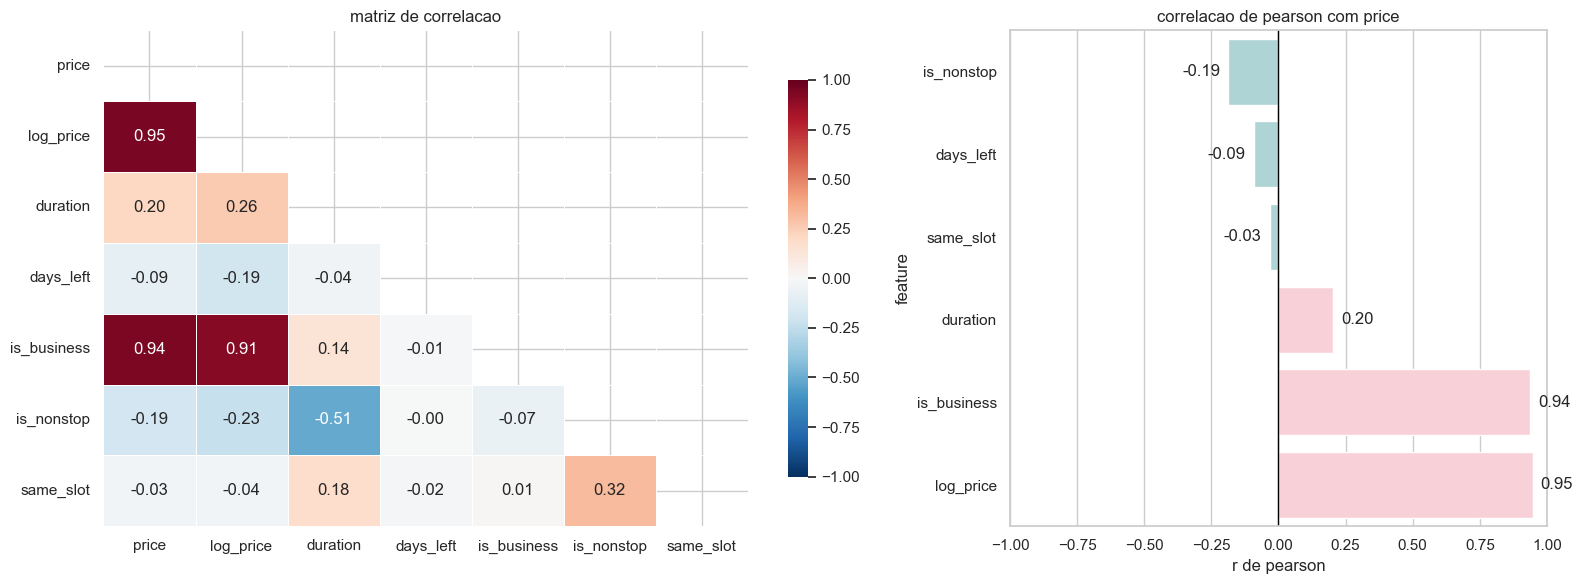

In [67]:
df_corr = df.copy()
if "log_price" not in df_corr.columns:
    df_corr["log_price"] = np.log1p(df_corr["price"])

corr_features = ["price", "log_price", "duration", "days_left", "is_business", "is_nonstop", "same_slot"]
corr_matrix = df_corr[corr_features].corr(method="pearson")
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

target_corr = (
    corr_matrix[["price"]]
    .drop(index="price")
    .rename(columns={"price": "pearson_r"})
    .sort_values("pearson_r")
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1.2, 0.8]})
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=axes[0],
)
axes[0].set_title("matriz de correlacao")

bar_colors = [PALETA_GRAFICOS[0] if v < 0 else PALETA_GRAFICOS[1] for v in target_corr["pearson_r"]]
sns.barplot(
    data=target_corr.reset_index(),
    x="pearson_r",
    y="index",
    hue="index",
    palette=bar_colors,
    dodge=False,
    ax=axes[1],
)
if axes[1].legend_:
    axes[1].legend_.remove()
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("correlacao de pearson com price")
axes[1].set_xlabel("r de pearson")
axes[1].set_ylabel("feature")
axes[1].set_xlim(-1, 1)

for i, value in enumerate(target_corr["pearson_r"]):
    axes[1].text(
        value + (0.03 if value >= 0 else -0.03),
        i,
        f"{value:.2f}",
        va="center",
        ha="left" if value >= 0 else "right",
    )

plt.tight_layout()
plt.show()

`class` aparece de forma muito clara como o principal driver de `price`
a correlação de `is_business` com o preço é disparada a maior da análise, o boxplot mostra uma separação entre `Economy` e `Business`. não parece ser só diferença de nível, mas sim dois regimes de preço convivendo na mesma base

depois de `class`, `duration` pode ser um sinal positivo relevante, embora bem mais fraco, enquanto `days_left` e `is_nonstop` têm relação negativa com o preço
o ponto mais importante aqui é que `stops` não pode ser lido de forma agregada. olhando só a média geral, voos com `one stop` parecem mais caros, mas quando a leitura é segmentada por `class` o padrão muda pois dentro de cada classe, mais escalas tende a vir acompanhado de preços maiores. ou seja, a média agregada de `stops` está misturando efeito de composição com efeito da variável. `same_slot`, por outro lado, quase não adiciona sinal

## 7. antecedência, classe e rota

- reservar perto da data do embarque parece encarecer muito mais a tarifa em `Economy`
- `route` ajuda a mostrar que parte do preço depende fortemente do trajeto
- essa combinação indica interações relevantes entre tempo de compra, classe e contexto operacional

,count,mean,median
days_bin,,,
1-7,32113,"26,451.2300","13,944.0000"
8-14,42805,"23,768.3600","12,118.0000"
15-21,45151,"20,201.0100","6,590.0000"
22-28,45525,"19,645.1900","6,132.0000"
29-35,45252,"19,440.4600","6,082.0000"
36-42,45624,"19,380.6900","6,067.0000"
43-49,43683,"19,066.3200","5,949.0000"


mean      median
class    days_bin                        
Business 1-7      56,745.0400 56,040.0000
         8-14     52,692.9000 53,209.0000
         15-21    52,287.9100 53,164.0000
         22-28    51,983.2800 53,071.0000
         29-35    51,844.1700 53,152.0000
         36-42    51,746.0900 52,715.0000
         43-49    51,466.6300 52,715.0000
Economy  1-7      11,633.7500 11,248.0000
         8-14     10,047.8100  9,945.0000
         15-21     6,009.1800  5,499.0000
         22-28     5,252.9700  5,092.0000
         29-35     5,050.3000  4,827.0000
         36-42     5,015.5200  4,792.0000
         43-49     4,792.6100  4,502.0000

,count,mean,median
route,,,
Chennai -> Bangalore,6493,"25,081.8500","10,469.0000"
Kolkata -> Chennai,6653,"23,660.3600","8,589.0000"
Bangalore -> Kolkata,10028,"23,500.0600","8,112.0000"
Bangalore -> Chennai,6410,"23,321.8500","9,241.0000"
Mumbai -> Bangalore,12885,"23,147.8700","7,192.0000"
Bangalore -> Mumbai,12939,"23,128.6200","7,113.0000"
Mumbai -> Chennai,10130,"22,781.9000","8,148.0000"
Chennai -> Mumbai,9338,"22,765.8500","8,233.0000"
Kolkata -> Bangalore,9824,"22,744.8100","8,111.0000"


,count,mean,median
route,,,
Hyderabad -> Mumbai,10064,"20,080.8700","6,633.0000"
Kolkata -> Delhi,10506,"19,422.3500","6,723.0000"
Delhi -> Chennai,10780,"19,369.8800","7,425.0000"
Delhi -> Mumbai,15289,"19,355.8300","7,262.0000"
Chennai -> Delhi,9783,"18,981.8600","7,352.0000"
Mumbai -> Delhi,14809,"18,725.3200","6,300.0000"
Delhi -> Bangalore,14012,"17,880.2200","6,642.0000"
Bangalore -> Delhi,13756,"17,723.3100","7,164.0000"
Delhi -> Hyderabad,9328,"17,347.2900","6,109.0000"


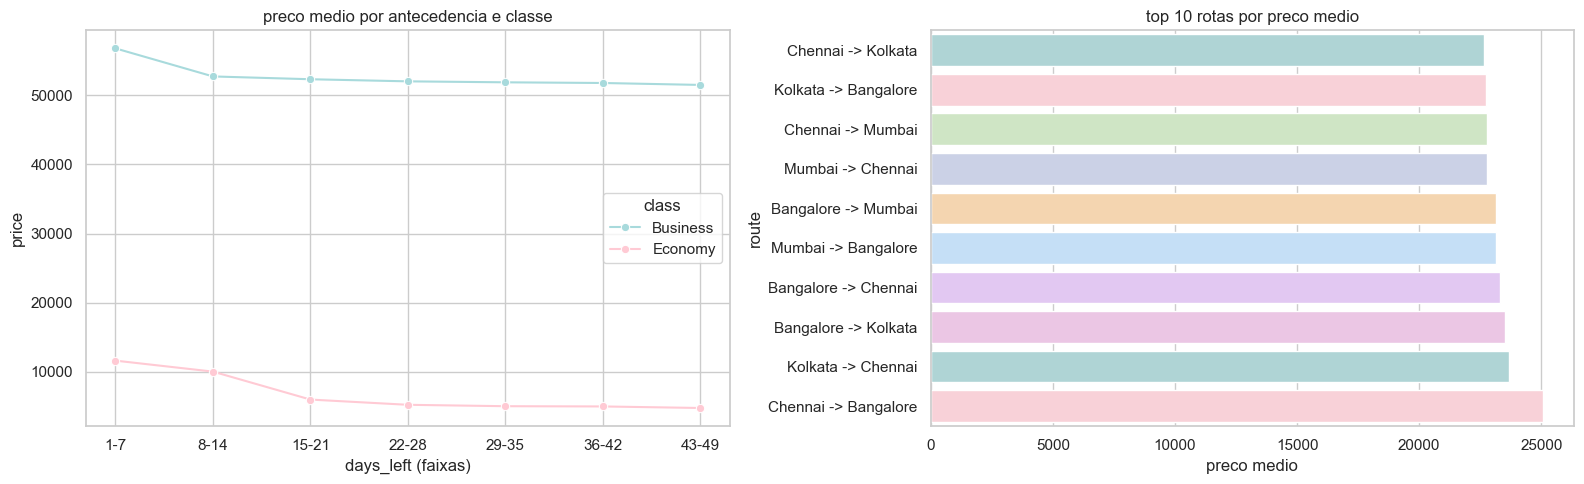

In [68]:
days_summary = df.groupby("days_bin", observed=False)["price"].agg(["count", "mean", "median"]).round(2)
days_class_summary = df.groupby(["class", "days_bin"], observed=False)["price"].agg(["mean", "median"]).round(2)
route_summary = (
    df.groupby("route")["price"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
    .round(2)
)

display(days_summary)
display(days_class_summary)
display(route_summary.head(10))
display(route_summary.tail(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
palette_classes = PALETA_GRAFICOS[: df["class"].nunique()]

sns.lineplot(
    data=df.groupby(["days_bin", "class"], observed=False)["price"].mean().reset_index(),
    x="days_bin",
    y="price",
    hue="class",
    palette=palette_classes,
    marker="o",
    ax=axes[0],
)
axes[0].set_title("preco medio por antecedencia e classe")
axes[0].set_xlabel("days_left (faixas)")

top_routes = route_summary.head(10).sort_values("mean").reset_index()
sns.barplot(
    data=top_routes,
    x="mean",
    y="route",
    hue="route",
    palette=PALETA_GRAFICOS,
    dodge=False,
    ax=axes[1],
)
if axes[1].legend_:
    axes[1].legend_.remove()
axes[1].set_title("top 10 rotas por preco medio")
axes[1].set_xlabel("preco medio")

plt.tight_layout()
plt.show()

a antecedência afeta o preço, mas não de forma homogênea. no agregado, existe uma queda do preço médio conforme a compra é feita mais cedo, mas a segmentação por `class` mostra de onde esse efeito vem. em `Economy`, comprar perto da data do voo encarece bastante a tarifa, enquanto em `Business` a curva é bem mais estável e continua em um patamar alto em toda a janela. então `days_left` tem sinal, mas ele funciona muito mais como interação com `class` do que como efeito isolado.

também podemos observar algumas informações relevnates em `route`. existe uma diferença entre rotas mais caras e mais baratas, o que mostra que o trajeto ajuda a explicar preço. 
ao mesmo tempo, a distância entre média e mediana em várias rotas sugere que esse efeito ainda está misturado com composição de classe e perfil do voo. na prática, isso reforça que antecedência importa principalmente em `Economy`, e `route` merece entrar na modelagem porque parece capturar uma parte estrutural do preço

## 8. implicações para modelagem

- `class` aparece como principal separador de preço e deve entrar no baseline
- `duration`, `days_left`, `stops` e principalmente `route` parecem carregar sinal útil para uma regressão linear regularizada
- `departure_time` e `arrival_time` podem agregar valor, mas efeitos mais fracos também podem ser testados
- `log1p(price)` melhora a distribuição da target e merece comparação com a target crua, sempre avaliando o desempenho na escala original do preço
- `flight` pode capturar sinal operacional importante, mas por ser uma variável de alta cardinalidade vale testar seu ganho incremental sobre `route` e `airline`, em vez de assumir que ela sempre melhora a generalização
- como `flight` já concentra bastante informação operacional, faz sentido verificar depois se `airline` ainda agrega valor ou só introduz redundância